# Example: Evaluation of the TTOA-NN model

This notebook demonstrates post-analysis examples for the TTOA-NN model. At the moment, no data is available. Se the paths in the configuration cell to files that you have access to on your local device.

The notebook covers the following:
1. Model performance on choice predictions
2. Model preformance on predicting moral stance scores
3. Plot the learned taboo signals between cost (secular) and non-cost (sacred) attributes
4. Plot the learned taboo penalty for sensitivity quartiles
5. Comparison moral stance predictions across quartiles of learned taboo aversion

**Note**: The plots describe the learned model, not causal effects. They should be interpreted together with the paper's identification assumptions, preprocessing description, uncertainty analysis, and out-of-sample evaluation. Please see the paper for more details: https://dx.doi.org/10.2139/ssrn.7276298

In [10]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FormatStrFormatter
import numpy as np
import pandas as pd
import seaborn as sns
import textwrap
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

from ttoann.dataloader import ChoiceData
from ttoann.measures import diagnose_ttoa, moral_stance_metrics
from ttoann.model import TTOA_NN
from ttoann.utils import evaluate_model, get_device

#------------------------------------------------------------------------
# Set up the repository root and import the model and dataloader modules
#------------------------------------------------------------------------

repo_root = Path.cwd()

if not (repo_root / "ttoann").exists():
    repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [2]:
#------------------------------------------------------------------------
# Model configuration and paths to data and checkpoint files
#------------------------------------------------------------------------

data_path = Path("data/data.csv")
checkpoint_path = Path("results/model_state_dict.pth")

model_pred = "choice-ttoa-full"
model_type = "multitask"
batch_size = 256
num_alts = 2

# These values must match the model used to create the checkpoint.
model_config = {
    "asu_layer_sizes": [7, 16, 8, 1],
    "cost_layer_sizes": [1, 4, 1],
    "taboo_layer_sizes": [6, 8, 4, 1],
    "z_layer_sizes": [16, 8, 4, 8],
    "text_layer_sizes": [30, 8, 8],
    "ttoa_layer_sizes": [16, 1],
    "moral_stance_layer_sizes": [16, 5],
    "ttoa_model": True,
    "z_model": True,
    "text_model": True,
    "activ_fn": "relu",
    "dropout": 0.1,
}

if not data_path.exists() or not checkpoint_path.exists():
    raise FileNotFoundError(
        "Set data_path and checkpoint_path to local files before running the example."
    )

device = get_device()
print(f"Using device: {device}")

Using device: mps


In [3]:
#----------------------------
# Load the dataset and model
#----------------------------

dataset = ChoiceData(
    data_path,
    model_type=model_type,
    model_pred=model_pred,
)

dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
model = TTOA_NN(**model_config).to(device)
checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
    weights_only=True,
)

if "model_state_dict" in checkpoint:
    checkpoint = checkpoint["model_state_dict"]

model.load_state_dict(checkpoint)
model.eval()

print(f"Observations: {len(dataset):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print("Sample variables:", sorted(dataset[0]))

===> Initializing choice-ttoa-full multitask dataset...
===> Dataset initialized!
Observations: 12,540
Trainable parameters: 1,017
Sample variables: ['respid', 'text', 'text_mask', 'x_cost', 'x_noncost', 'x_taboo', 'y', 'y_2', 'z']


In [4]:
#-----------------------------------------
# Evaluate the model's choice predictions
#-----------------------------------------

choice_metrics = evaluate_model(
    model,
    dataloader,
    device=device,
    model_pred=model_pred,
    num_alts=num_alts,
)

for name, value in choice_metrics.items():
    print(f"{name}: {value:.4f}" if isinstance(value, float) else f"{name}: {value}")

ll: -8007.9184
null_ll: -8665.2365
rho_squared: 0.0759
n_observations: 12540
moral_mse: 0.0023


In [5]:
#----------------------------------------------------------------
# Evaluate the model's moral stance predictions
#   * only for observations whose text documents are informative
#----------------------------------------------------------------

moral_metrics = moral_stance_metrics(model, dataloader, device=device)

for name, value in moral_metrics.items():
    print(f"{name}: {value:.4f}" if isinstance(value, float) else f"{name}: {value}")

mse: 0.0023
rmse: 0.0478
r2: 0.9095
n_observations: 11664


In [6]:
#---------------------------------------------------------------
# Inspect the learned TTOA and taboo signal on population-level
#---------------------------------------------------------------

diagnostics = diagnose_ttoa(model, dataloader, device=device)

print("Summary:")
for name, value in diagnostics["summary"].items():
    print(f"  {name}: {value:.4f}")

Summary:
  tau_mean: 1.7274
  tau_std: 1.7736
  h_s_mean: -0.1030
  h_s_std: 0.1657
  h_s_negative_fraction: 1.0000
  penalty_abs_mean: 0.1807
  baseline_abs_mean: 0.5045
  penalty_to_baseline: 0.3582


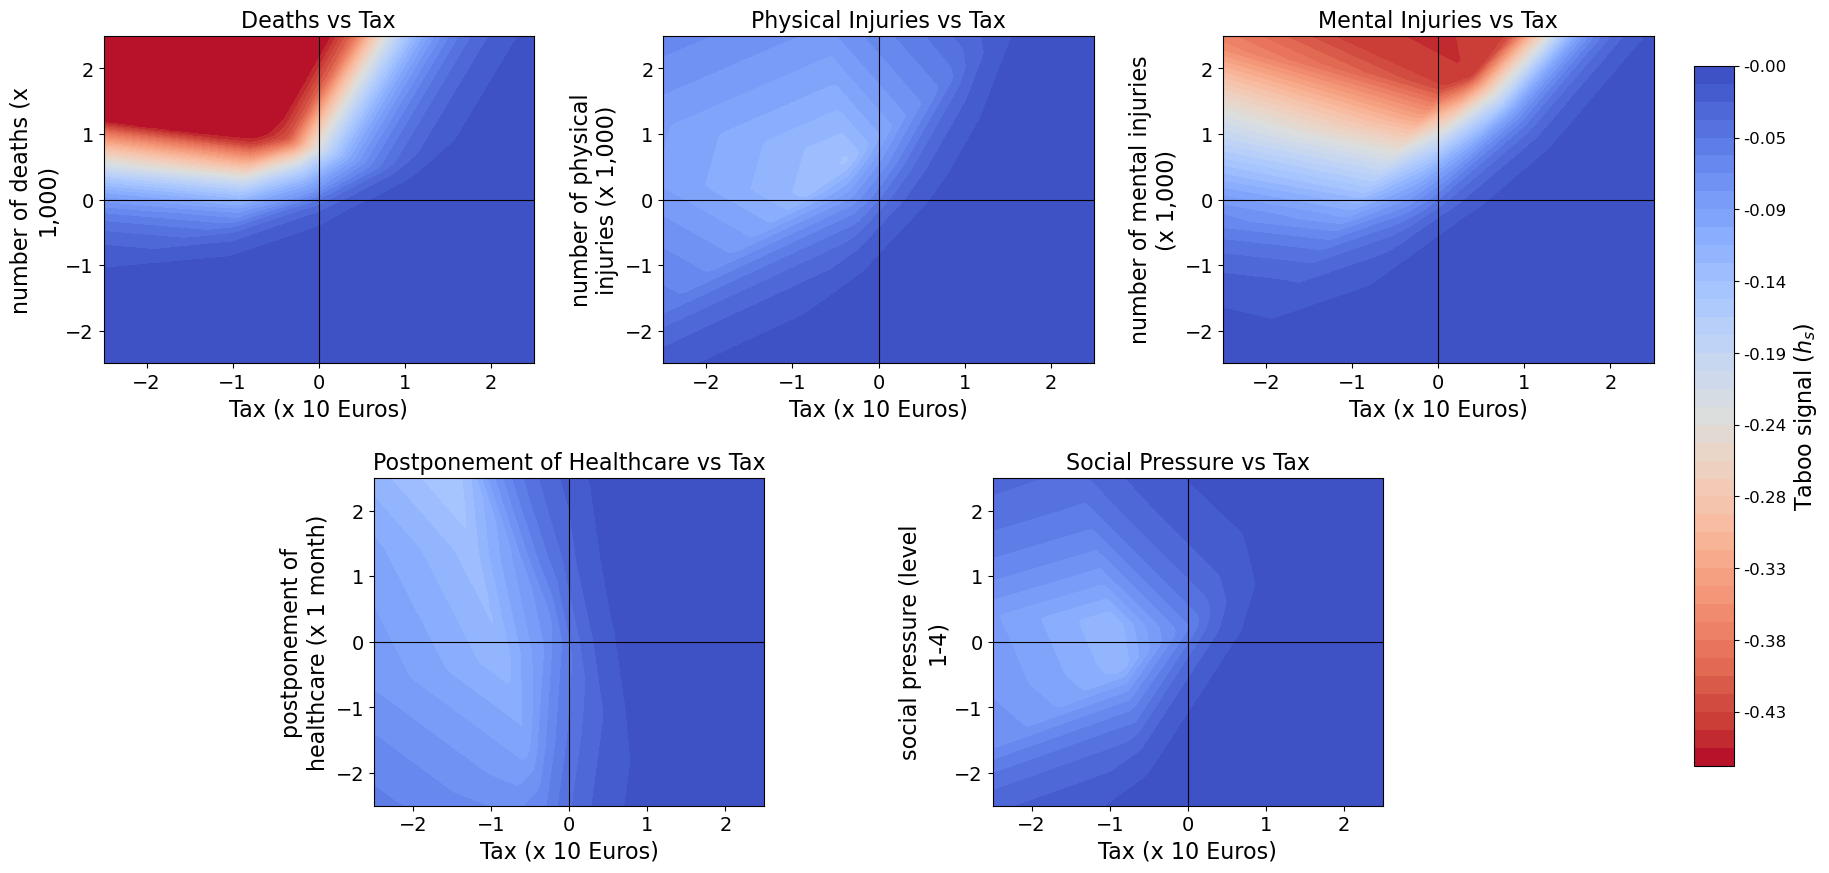

In [7]:
#--------------------------------------------------------------------
# Plot the learned taboo signal between cost and non-cost attributes
#--------------------------------------------------------------------

def wrap_ylabel(ax, text, width=25, fontsize=14):
    """
    Wraps the y-axis label text dynamically.

    ax      : matplotlib Axes object
    text    : string, label
    width   : max number of characters per line
    fontsize: font size
    """
    wrapped = "\n".join(textwrap.wrap(text, width=width))
    ax.set_ylabel(wrapped, fontsize=fontsize)

taboo_names = (
    "delta_death", "delta_pinjury", "delta_minjury",
    "delta_phealth", "delta_spressure", "delta_tax",
)

attribute_labels = (
    "Deaths", "Physical Injuries", "Mental Injuries",
    "Postponement of Healthcare", "Social Pressure",
)

attribute_axis_labels = (
    "number of deaths (x 1,000)",
    "number of physical injuries (x 1,000)",
    "number of mental injuries (x 1,000)",
    "postponement of healthcare (x 1 month)",
    "social pressure (level 1-4)",
)

n_grid = 80
normalized_values = torch.linspace(-2.5, 2.5, n_grid, device=device)
tax_index = taboo_names.index("delta_tax")
tax_values = normalized_values.cpu().numpy()

responses = []

for attribute_index, attribute_name in enumerate(taboo_names[:-1]):
    grid_tax, grid_attribute = torch.meshgrid(
        normalized_values,
        normalized_values,
        indexing="xy",
    )

    taboo_input = torch.zeros(
        grid_tax.numel(), len(taboo_names), device=device
    )

    taboo_input[:, tax_index] = grid_tax.reshape(-1)
    taboo_input[:, attribute_index] = grid_attribute.reshape(-1)

    with torch.no_grad():
        signal = -torch.sigmoid(model.taboo_layers(taboo_input))

    responses.append(
        (
            attribute_name,
            normalized_values.cpu().numpy(),
            signal.reshape(n_grid, n_grid).cpu().numpy(),
        )
    )

color_min = min(signal.min() for _, _, signal in responses)
color_max = max(signal.max() for _, _, signal in responses)
levels = np.linspace(color_min, color_max, 40)

fig = plt.figure(figsize=(20, 10))

outer_grid = gridspec.GridSpec(
    2, 1, height_ratios=[1, 1], hspace=0.35
)

# Top row: three panels.
top_grid = gridspec.GridSpecFromSubplotSpec(
    1, 3, subplot_spec=outer_grid[0], wspace=0.3
)

axes = []

for index in range(3):
    axis = fig.add_subplot(top_grid[0, index])
    axes.append(axis)
    _, attribute_values, signal = responses[index]
    tax_grid, attribute_grid = np.meshgrid(tax_values, attribute_values)

    image = axis.contourf(
        tax_grid,
        attribute_grid,
        signal,
        levels=levels,
        cmap="coolwarm_r",
        vmin=color_min,
        vmax=color_max,
    )

    axis.tick_params(axis="both", labelsize=14)
    axis.axvline(0, color="black", linewidth=0.8)
    axis.axhline(0, color="black", linewidth=0.8)
    axis.set_xlabel("Tax (x 10 Euros)", fontsize=16)
    wrap_ylabel(axis, attribute_axis_labels[index], fontsize=16)
    axis.set_title(f"{attribute_labels[index]} vs Tax", fontsize=16)

# Bottom row: two centered panels with the same width as the top panels
bottom_grid = gridspec.GridSpecFromSubplotSpec(
    1,
    5,
    subplot_spec=outer_grid[1],
    width_ratios=[0.5, 1, 0.2, 1, 0.5],
    wspace=0.3,
)

for panel_position, index in enumerate(range(3, 5)):
    column = panel_position * 2 + 1
    axis = fig.add_subplot(bottom_grid[0, column])
    axes.append(axis)

    _, attribute_values, signal = responses[index]
    tax_grid, attribute_grid = np.meshgrid(tax_values, attribute_values)

    image = axis.contourf(
        tax_grid,
        attribute_grid,
        signal,
        levels=levels,
        cmap="coolwarm_r",
        vmin=color_min,
        vmax=color_max,
    )

    axis.tick_params(axis="both", labelsize=14)
    axis.axvline(0, color="black", linewidth=0.8)
    axis.axhline(0, color="black", linewidth=0.8)
    axis.set_xlabel("Tax (x 10 Euros)", fontsize=16)
    wrap_ylabel(axis, attribute_axis_labels[index], fontsize=16)
    axis.set_title(f"{attribute_labels[index]} vs Tax", fontsize=16)

colorbar_axis = fig.add_axes([0.92, 0.15, 0.02, 0.7])
colorbar = fig.colorbar(image, cax=colorbar_axis)
colorbar.set_label(r"Taboo signal ($h_s$)", fontsize=16)
colorbar.ax.tick_params(labelsize=12)
colorbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))

plt.show()

Q1 — Lowest 25% (τ = 0.03): n = 3,144
Q2 — 25-50% (τ = 0.08): n = 3,132
Q3 — 50-75% (τ = 2.91): n = 3,132
Q4 — Highest 25% (τ = 3.90): n = 3,132


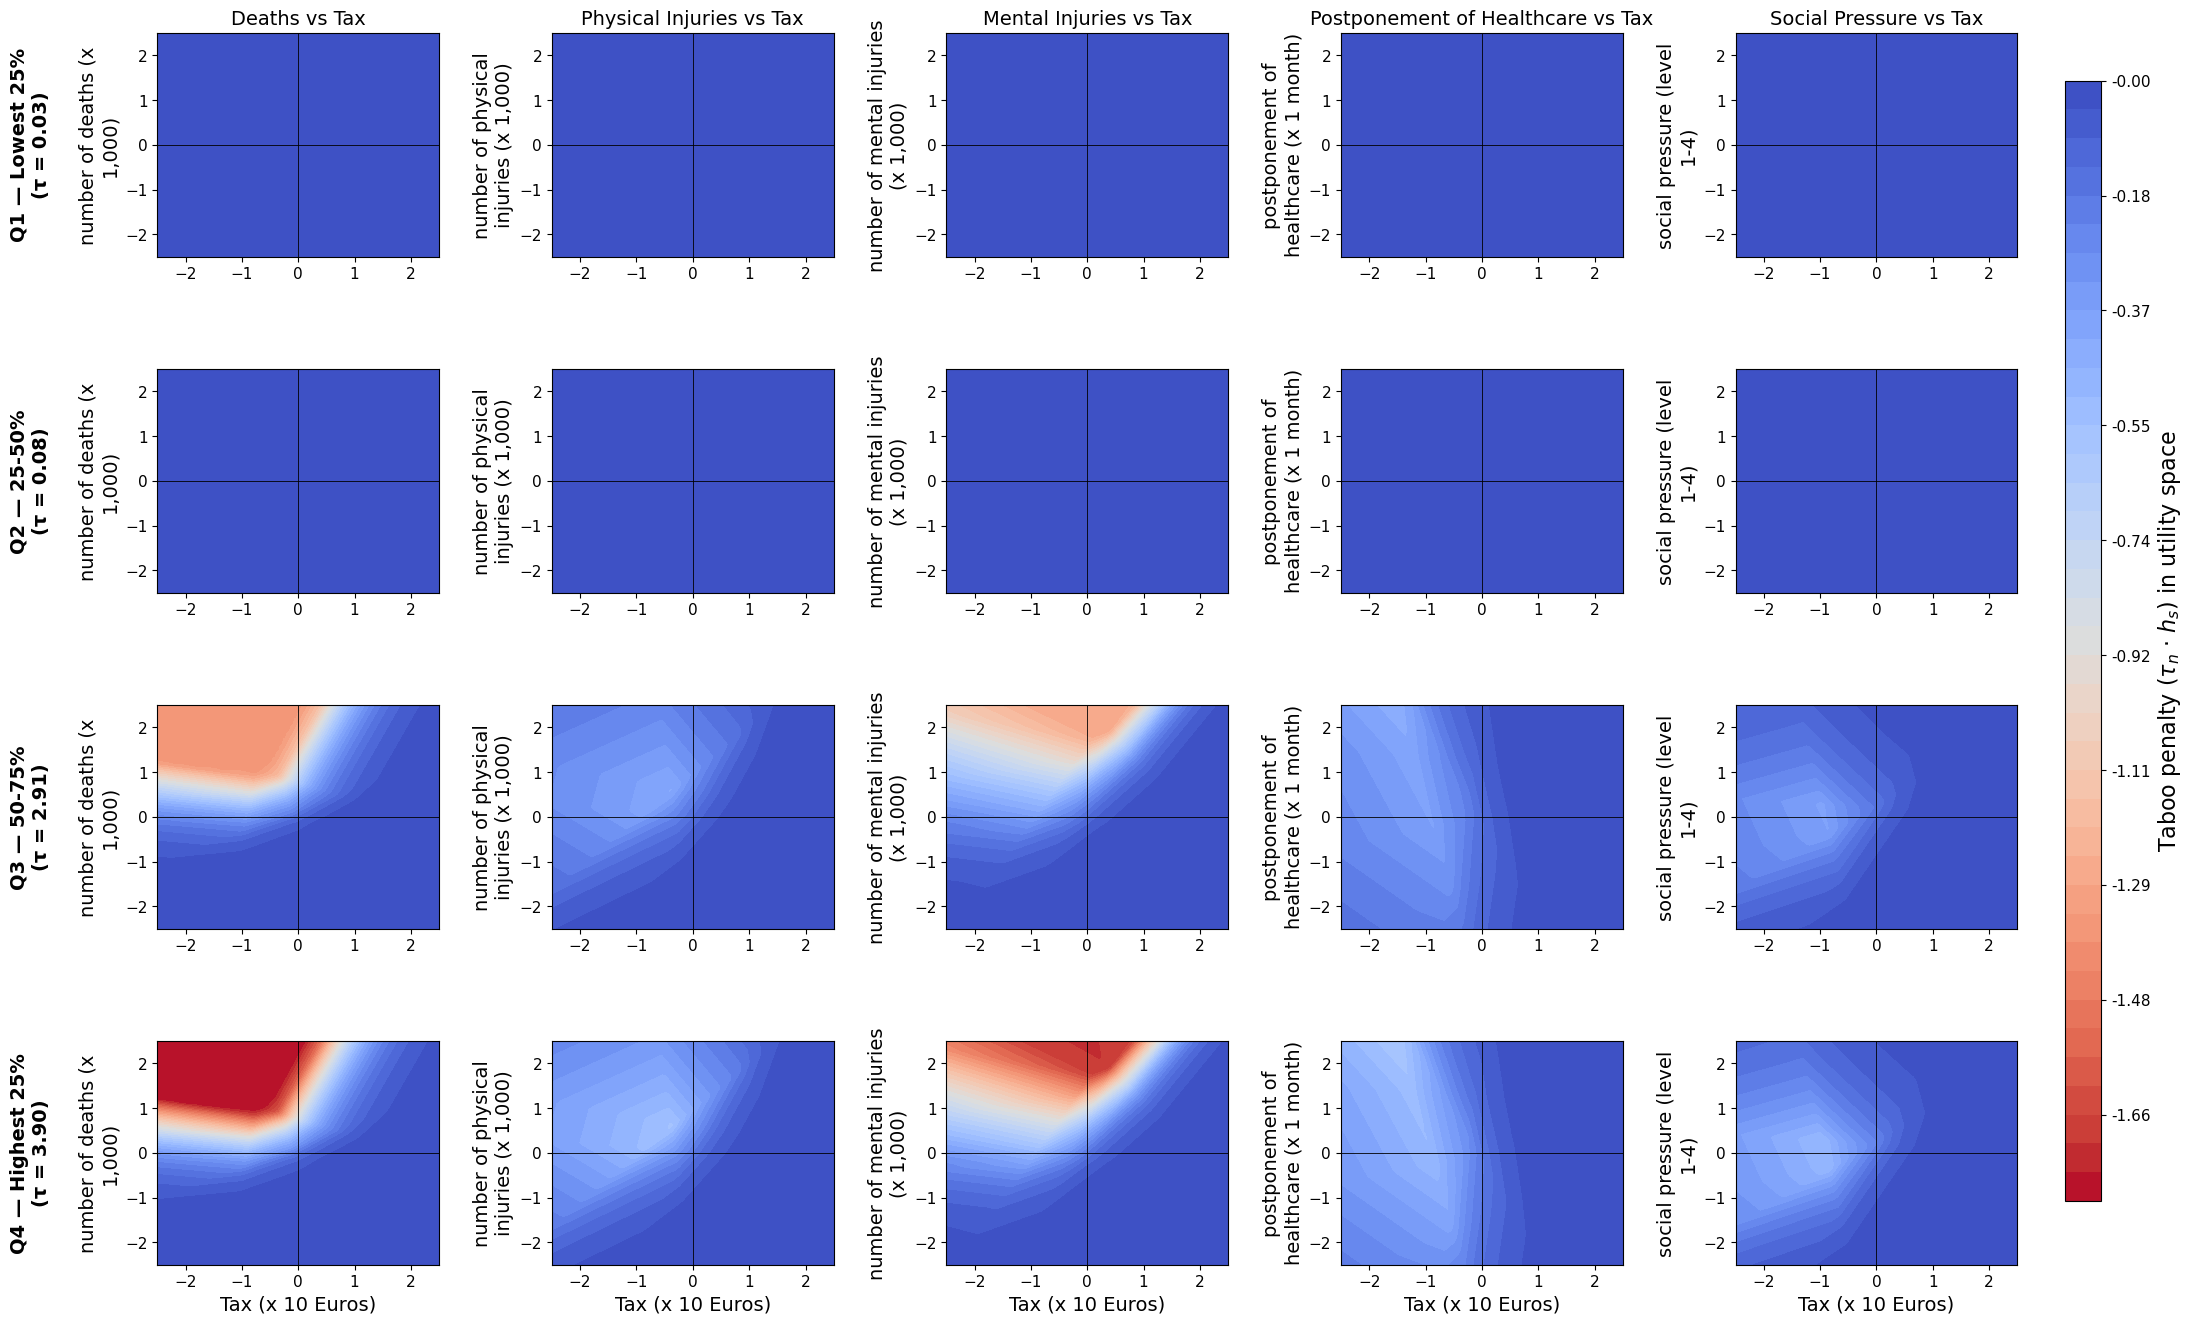

In [ ]:
#----------------------------------------------------------
# Plot the learned taboo penalty for sensitivity quartiles
#----------------------------------------------------------

tau_values = diagnostics["tau_n"].flatten().numpy()
quartile_edges = np.quantile(tau_values, [0.25, 0.50, 0.75])

quartile_groups = (
    tau_values[tau_values <= quartile_edges[0]],
    tau_values[(tau_values > quartile_edges[0]) & (tau_values <= quartile_edges[1])],
    tau_values[(tau_values > quartile_edges[1]) & (tau_values <= quartile_edges[2])],
    tau_values[tau_values > quartile_edges[2]],
)

quartile_means = [group.mean() for group in quartile_groups]

quartile_labels = [
    f"Q1 — Lowest 25%\n(τ = {quartile_means[0]:.2f})",
    f"Q2 — 25-50%\n(τ = {quartile_means[1]:.2f})",
    f"Q3 — 50-75%\n(τ = {quartile_means[2]:.2f})",
    f"Q4 — Highest 25%\n(τ = {quartile_means[3]:.2f})"
]

for label, group in zip(quartile_labels, quartile_groups):
    print(f"{label.replace(chr(10), ' ')}: n = {len(group):,}")

penalty_surfaces = [
    [sensitivity * signal for _, _, signal in responses]
    for sensitivity in quartile_means
]

global_vmin = min(
    surface.min() for row in penalty_surfaces for surface in row
)

global_vmax = max(
    surface.max() for row in penalty_surfaces for surface in row
)

global_levels = np.linspace(global_vmin, global_vmax, 40)

fig = plt.figure(figsize=(24, 16))

grid = gridspec.GridSpec(
    nrows=4,
    ncols=5,
    hspace=0.5,
    wspace=0.4,
)

for row_index, (quartile_mean, row_surfaces) in enumerate(
    zip(quartile_means, penalty_surfaces)
):
    for column_index, ((attribute_name, attribute_values, _), surface) in enumerate(
        zip(responses, row_surfaces)
    ):
        axis = fig.add_subplot(grid[row_index, column_index])
        tax_grid, attribute_grid = np.meshgrid(tax_values, attribute_values)

        image = axis.contourf(
            tax_grid,
            attribute_grid,
            surface,
            levels=global_levels,
            vmin=global_vmin,
            vmax=global_vmax,
            cmap="coolwarm_r",
        )

        axis.tick_params(axis="both", labelsize=11)
        axis.axvline(0, color="black", linewidth=0.6)
        axis.axhline(0, color="black", linewidth=0.6)

        if row_index == 0:
            axis.set_title(
                f"{attribute_labels[column_index]} vs Tax",
                fontsize=14,
            )

        if column_index == 0:
            axis.text(
                -0.45,
                0.5,
                quartile_labels[row_index],
                transform=axis.transAxes,
                fontsize=14,
                fontweight="bold",
                ha="center",
                va="center",
                rotation=90,
            )

        wrap_ylabel(axis, attribute_axis_labels[column_index], width=25, fontsize=14)

        if row_index == 3:
            axis.set_xlabel("Tax (x 10 Euros)", fontsize=14)

colorbar_axis = fig.add_axes([0.92, 0.15, 0.015, 0.7])
colorbar = fig.colorbar(image, cax=colorbar_axis)

colorbar.set_label(
    r"Taboo penalty ($\tau_n$ · $h_s$) in utility space",
    fontsize=16,
)

colorbar.ax.tick_params(labelsize=11)
colorbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))

plt.show()

Informative observations: 11,664
Q1: n = 2,916, mean tau = 0.028
Q2: n = 2,916, mean tau = 0.238
Q3: n = 2,916, mean tau = 3.246
Q4: n = 2,916, mean tau = 3.909


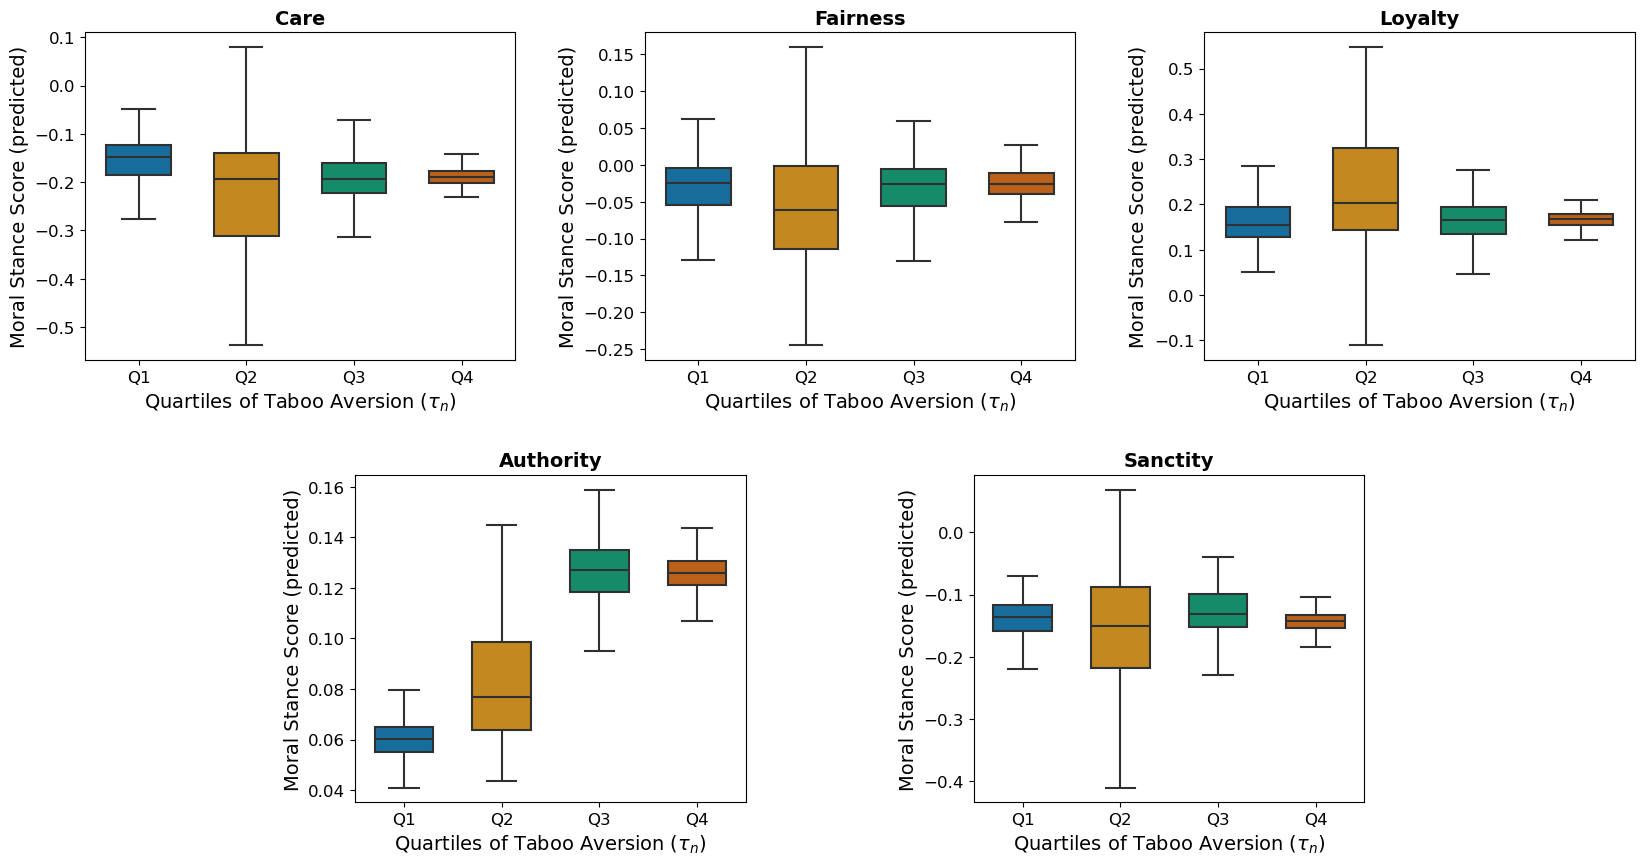

In [9]:
#-----------------------------------------------------------------------------
# Compare moral stance predictions across quartiles of learned taboo aversion
#-----------------------------------------------------------------------------

from ttoann.utils import move_batch_to_device

model.eval()

tau_batches = []
moral_batches = []
mask_batches = []

with torch.no_grad():
    for batch in dataloader:
        batch = move_batch_to_device(batch, device)
        z_out = model.z_layers(batch["z"])
        text_out = model.text_layers(batch["text"])

        latent = torch.cat(
            [
                F.layer_norm(z_out, z_out.shape[1:]),
                F.layer_norm(text_out, text_out.shape[1:]),
            ],
            dim=-1,
        )

        tau_batches.append(F.softplus(model.ttoa_layers(latent)).cpu())
        moral_batches.append(model.moral_stance_layers(latent).cpu())
        mask_batches.append(batch["text_mask"].cpu().bool().squeeze(1))

tau_values = torch.cat(tau_batches).flatten().numpy()
moral_values = torch.cat(moral_batches).numpy()
informative_mask = torch.cat(mask_batches).numpy()

# Restrict the comparison to observations used by the auxiliary task
tau_values = tau_values[informative_mask]
moral_values = moral_values[informative_mask]

quartile_edges = np.quantile(tau_values, [0.25, 0.50, 0.75])
quartile_indices = np.digitize(tau_values, quartile_edges, right=True)
quartile_names = ["Q1", "Q2", "Q3", "Q4"]
moral_names = ("Care", "Fairness", "Loyalty", "Authority", "Sanctity")

print(f"Informative observations: {len(tau_values):,}")

for quartile_index, quartile_name in enumerate(quartile_names):
    values = tau_values[quartile_indices == quartile_index]

    print(
        f"{quartile_name}: n = {len(values):,}, "
        f"mean tau = {values.mean():.3f}"
    )

ordered_quartiles = pd.Categorical(
    [quartile_names[index] for index in quartile_indices],
    categories=quartile_names,
    ordered=True,
)

figure = plt.figure(figsize=(20, 10))

outer_grid = gridspec.GridSpec(
    2,
    1,
    height_ratios=[1, 1],
    hspace=0.35,
)

top_grid = gridspec.GridSpecFromSubplotSpec(
    1,
    3,
    subplot_spec=outer_grid[0],
    wspace=0.3,
)

for foundation_index in range(3):
    axis = figure.add_subplot(top_grid[0, foundation_index])

    plot_data = pd.DataFrame({
        "tau_quartile": ordered_quartiles,
        "moral_score": moral_values[:, foundation_index],
    })

    sns.boxplot(
        x="tau_quartile",
        y="moral_score",
        hue="tau_quartile",
        hue_order=quartile_names,
        order=quartile_names,
        data=plot_data,
        palette="colorblind",
        showfliers=False,
        width=0.6,
        linewidth=1.5,
        legend=False,
        ax=axis,
    )

    axis.set_xlabel("Quartiles of Taboo Aversion ($τ_n$)", fontsize=14)
    axis.set_ylabel("Moral Stance Score (predicted)", fontsize=14)
    axis.set_title(moral_names[foundation_index], fontsize=14, fontweight="bold")
    axis.tick_params(axis="both", labelsize=12)

bottom_grid = gridspec.GridSpecFromSubplotSpec(
    1,
    5,
    subplot_spec=outer_grid[1],
    width_ratios=[0.5, 1, 0.2, 1, 0.5],
    wspace=0.3,
)

for panel_position, foundation_index in enumerate(range(3, 5)):
    column = panel_position * 2 + 1
    axis = figure.add_subplot(bottom_grid[0, column])
    plot_data = pd.DataFrame({
        "tau_quartile": ordered_quartiles,
        "moral_score": moral_values[:, foundation_index],
    })

    sns.boxplot(
        x="tau_quartile",
        y="moral_score",
        hue="tau_quartile",
        hue_order=quartile_names,
        order=quartile_names,
        data=plot_data,
        palette="colorblind",
        showfliers=False,
        width=0.6,
        linewidth=1.5,
        legend=False,
        ax=axis,
    )
    
    axis.set_xlabel("Quartiles of Taboo Aversion ($τ_n$)", fontsize=14)
    axis.set_ylabel("Moral Stance Score (predicted)", fontsize=14)
    axis.set_title(moral_names[foundation_index], fontsize=14, fontweight="bold")
    axis.tick_params(axis="both", labelsize=12)

plt.show()

## Interpretation notes

These plots describe the learned model, not causal effects. They should be interpreted together with the paper's identification assumptions, preprocessing description, uncertainty analysis, and out-of-sample evaluation. Please see the paper for more details: https://dx.doi.org/10.2139/ssrn.7276298